# Classification de genre des hôtes à partir des commentaires

Ce carnet utilise **ollama** avec le modèle `gemma3:4b` pour déterminer le genre associé au nom de l'hôte (`reviewer_name`). Les catégories possibles sont : **Homme**, **Femme**, **Couple**, **Épicène**, et **Entreprise**. Nous verrons les 1000 premières lignes du fichier `reviews_select.csv`.

## 1. Setup Environment

Configurer l'environnement pour exécuter des commandes système et s'assurer que les chemins sont corrects.

In [29]:
import os
# Définir le répertoire de travail, si nécessaire
base_dir = os.getcwd()
print(f"Working directory: {base_dir}")


Working directory: c:\Users\33623\Documents\_AtelierR\___Ranking and reviews data\airbnbJO2024\AirBnB_NLP4socialscience


## 2. Import Libraries

Importer les bibliothèques nécessaires : pandas pour la manipulation de données et subprocess pour appeler Ollama.

In [30]:
import pandas as pd
import subprocess
from tqdm import tqdm

# Vérifier qu'ollama est accessible
!ollama --help

Large language model runner

Usage:
  ollama [flags]
  ollama [command]

Available Commands:
  serve       Start Ollama
  create      Create a model
  show        Show information for a model
  run         Run a model
  stop        Stop a running model
  pull        Pull a model from a registry
  push        Push a model to a registry
  signin      Sign in to ollama.com
  signout     Sign out from ollama.com
  list        List models
  ps          List running models
  cp          Copy a model
  rm          Remove a model
  launch      Launch the Ollama menu or an integration
  help        Help about any command

Flags:
  -h, --help         help for ollama
      --nowordwrap   Don't wrap words to the next line automatically
      --verbose      Show timings for response
  -v, --version      Show version information

Use "ollama [command] --help" for more information about a command.


## 3. Load Data

Charger le fichier CSV et sélectionner les 1000 premières lignes.

In [31]:
csv_path = os.path.join('data', 'reviews_select.csv')
df = pd.read_csv(csv_path, nrows=1000)
df.head()


,Unnamed: 0,listing_id,id,date,reviewer_id,reviewer_name,comments,langue,langue_short,nwords
0,1,5396,916489788146905600,2023-06-18,497745629,Grazia,"Alloggio confortevole e pratico, dotato di tut...",it,Latin,18
1,2,5396,921600086982789760,2023-06-25,70206366,Benjamin,Très bon emplacement pour cet appartement typi...,fr,French,27
2,3,5396,926663219961790080,2023-07-02,41320355,Julia,"What a wonderful gem. Great location, it was ...",en,English,28
3,4,5396,928819963905476608,2023-07-05,259277676,GLori,We had a lovely 3 night stay. Everything was ...,en,English,31
4,5,5396,929517734275725952,2023-07-06,93503104,James,Great location. Very calm and quiet. Small but...,en,English,31


## 4. Data Preprocessing

Aucun nettoyage majeur n'est prévu pour ce jeu de données restreint. Nous inspectons simplement les colonnes pertinentes.

In [32]:
df.columns


Index(['Unnamed: 0', 'listing_id', 'id', 'date', 'reviewer_id',
       'reviewer_name', 'comments', 'langue', 'langue_short', 'nwords'],
      dtype='object')

## 5. Exploratory Data Analysis

Examiner rapidement les noms et les commentaires pour avoir un aperçu.

In [33]:
for i, row in df.iterrows():
    print(i, row['reviewer_name'], '-', row['comments'][:60])


0 Grazia - Alloggio confortevole e pratico, dotato di tutto quello che 
1 Benjamin - Très bon emplacement pour cet appartement typique au cœur d 
2 Julia - What a wonderful gem.  Great location, it was spotless and t
3 GLori - We had a lovely 3 night stay.  Everything was just as descri
4 James - Great location. Very calm and quiet. Small but bigger than a
5 Allison - we loved this apartment, very convenient, easy to get to all
6 Lisa - Awesome communication via texting to insure an easy check-in
7 Fanny - Nice place best spot
8 Phidelia - Lovely home in a quaint and serene neighborhood. The apartme
9 Mohamed - Borzou’s apartment is, in my humble opinion, in the most vib
10 Gilles - Wonderful location. They did change the couch! We had no com
11 Katie - A lovely little apartment in the very centre of Paris!! We c
12 Natalie - Cute studio apartment in Paris... walking distance to many s
13 Steffen - Meine Freundin und ich hatten einen schönen Aufenthalt in de
14 Tam And Gwen - Fantastic

## 6. Visualization

Pas de visualisation nécessaire pour cette tâche ponctuelle.

## 7. Save or Export Results

Classifier chaque enregistrement via Ollama et sauvegarder les résultats.

In [34]:
# nouvelle cellule de classification corrigée
from datetime import datetime
categories = ["Homme", "Femme", "Couple", "Épicène", "Entreprise"]

def classify(name, comment):
    prompt = (
        f"Vous êtes un assistant. Classez le nom de l'hôte (reviewer_name) dans une des catégories suivantes : {', '.join(categories)}.\n"
        f"N'utilisez que le nom et éventuellement le commentaire pour déterminer le genre.\n"
        f"Répondez uniquement par un mot parmi les catégories, sans autre texte.\n"
        f"Nom : {name}\nCommentaire : {comment}\n"
    )
    proc = subprocess.run(
        ['ollama', 'run', 'gemma3:4b'],
        input=prompt.encode('utf-8'),
        stdout=subprocess.PIPE,
    )
    out = proc.stdout.decode('utf-8').strip().splitlines()[0] if proc.stdout else ''
    return out

# Appliquer la classification avec une barre de progression et chronométrage
import time
start_time = time.time()
results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classification Gemma", miniters=10):
    gender = classify(row['reviewer_name'], row.get('comments', '')).capitalize()
    results.append(gender)
end_time = time.time()

df['gender'] = results
df['comment_id'] = df.index
df['date_classification'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
out = df[['comment_id', 'reviewer_name', 'comments', 'gender', 'date_classification']]
out.to_csv('first1000_gender.csv', index=False)

# Calculer les statistiques
elapsed_time = end_time - start_time
num_items = len(df)
items_per_second = num_items / elapsed_time if elapsed_time > 0 else 0

# Créer un dataframe avec les statistiques
stats_df = pd.DataFrame({
    'model': ['gemma3:4b'],
    'nombre_items': [num_items],
    'temps_total_secondes': [round(elapsed_time, 2)],
    'items_par_seconde': [round(items_per_second, 2)]
})

# Sauvegarder les statistiques
stats_df.to_csv('gemma_classification_stats.csv', index=False)
print("\nStatistiques de classification :")
print(stats_df)
print(f"\nStatistiques sauvegardées dans 'gemma_classification_stats.csv'")

out


Classification Gemma: 100%|██████████| 1000/1000 [36:03<00:00,  2.16s/it] 


Statistiques de classification :
       model  nombre_items  temps_total_secondes  items_par_seconde
0  gemma3:4b          1000                2163.2               0.46

Statistiques sauvegardées dans 'gemma_classification_stats.csv'


,comment_id,reviewer_name,comments,gender,date_classification
0,0,Grazia,"Alloggio confortevole e pratico, dotato di tut...",Femme,2026-02-21 15:09:02
1,1,Benjamin,Très bon emplacement pour cet appartement typi...,Homme,2026-02-21 15:09:02
2,2,Julia,"What a wonderful gem. Great location, it was ...",Femme,2026-02-21 15:09:02
3,3,GLori,We had a lovely 3 night stay. Everything was ...,Femme,2026-02-21 15:09:02
4,4,James,Great location. Very calm and quiet. Small but...,Homme,2026-02-21 15:09:02
...,...,...,...,...,...
995,995,Balázs,"A lakás pontosan olyan mint a hirdetésben, jól...",Homme,2026-02-21 15:09:02
996,996,Christian,"Carol fue muy amable en todo momento , incluso...",Homme,2026-02-21 15:09:02
997,997,Madeline,We loved staying in this apartment! This place...,Femme,2026-02-21 15:09:02
998,998,Hastings,"Great little spot for two in the 9th, super co...",Couple,2026-02-21 15:09:02


## 7b. Vérification avec Gemma et Score de Certitude

Vérifier chaque classification avec le modèle Gemma et ajouter un score de certitude de 0 à 1.


In [35]:
# Charger le fichier de résultats
results_df = pd.read_csv('first1000_gender.csv')

def verify_gender_with_granite(name, comment, assigned_gender):
    """
    Vérifier la classification avec Gemma et retourner un score de certitude (0 à 1)
    """
    prompt = (
        f"Vous êtes un expert en classification de genres. Etes-vous d'accord avec "
        f"la classification du nom '{name}' comme '{assigned_gender}'?\n"
        f"Commentaire : {comment}\n"
        f"Répondez UNIQUEMENT par OUI ou NON, sans autre texte.\n"
    )
    try:
        proc = subprocess.run(
            ['ollama', 'run', 'gemma3:4b'],
            input=prompt.encode('utf-8'),
            stdout=subprocess.PIPE,
            timeout=30
        )
        out = proc.stdout.decode('utf-8').strip().upper() if proc.stdout else 'NON'
        # Debug : afficher la réponse brute
        print(f"Réponse brute: '{out}'")
        # Convertir OUI/NON en score
        if 'OUI' in out:
            return 1.0
        elif 'NON' in out:
            return 0.0
        else:
            return 0.5  # Valeur par défaut si réponse ambiguë
    except Exception as e:
        print(f"Erreur: {e}")
        return 0.5  # Valeur par défaut en cas d'erreur

# Appliquer la vérification sur l'ensemble des données
print("Vérification sur l'ensemble des données :\n")
confidence_scores = []
for idx, row in tqdm(results_df.iterrows(), total=len(results_df), desc="Vérification Gemma", miniters=20):
    score = verify_gender_with_granite(row['reviewer_name'], row['comments'], row['gender'])
    confidence_scores.append(score)

results_df['confidence_score'] = confidence_scores
results_df['date_verification'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Sauvegarder les résultats enrichis
results_df.to_csv('first1000_gender.csv', index=False)
print("\nRésultats enrichis sauvegardés dans 'first1000_gender.csv'")
results_df.head(10)


Vérification Gemma:  66%|██████▌   | 660/1000 [22:41<16:06,  2.84s/it]

Réponse brute: 'OUI'


Vérification Gemma:  66%|██████▌   | 661/1000 [22:44<16:02,  2.84s/it]

Réponse brute: 'NON'


Vérification Gemma:  66%|██████▌   | 662/1000 [22:46<14:43,  2.61s/it]

...

Vérification Gemma: 100%|█████████▉| 999/1000 [35:29<00:02,  2.22s/it]

Réponse brute: 'OUI'


Vérification Gemma: 100%|██████████| 1000/1000 [35:31<00:00,  2.13s/it]

Réponse brute: 'NON'

Résultats enrichis sauvegardés dans 'first1000_gender.csv'


,comment_id,reviewer_name,comments,gender,date_classification,confidence_score,date_verification
0,0,Grazia,"Alloggio confortevole e pratico, dotato di tut...",Femme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34
1,1,Benjamin,Très bon emplacement pour cet appartement typi...,Homme,2026-02-21 15:09:02,0.0,2026-02-21 15:44:34
2,2,Julia,"What a wonderful gem. Great location, it was ...",Femme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34
3,3,GLori,We had a lovely 3 night stay. Everything was ...,Femme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34
4,4,James,Great location. Very calm and quiet. Small but...,Homme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34
5,5,Allison,"we loved this apartment, very convenient, easy...",Femme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34
6,6,Lisa,Awesome communication via texting to insure an...,Femme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34
7,7,Fanny,Nice place best spot,Femme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34
8,8,Phidelia,Lovely home in a quaint and serene neighborhoo...,Femme,2026-02-21 15:09:02,0.0,2026-02-21 15:44:34
9,9,Mohamed,"Borzou’s apartment is, in my humble opinion, i...",Homme,2026-02-21 15:09:02,1.0,2026-02-21 15:44:34


In [36]:
import time
from datetime import datetime

# Charger le fichier de résultats
results_df = pd.read_csv('first1000_gender.csv')

def verify_gender_with_granite(name, comment, assigned_gender):
    """
    Vérifier la classification avec Gemma et retourner un OUI si la classification est correcte sinon un NON
    """
    prompt = (
        f"Vous êtes un expert en classification de genres. Etes vous d'accord ou non avec "
        f"la classification du nom '{name}' comme '{assigned_gender}'.\n"
        f"Commentaire : {comment}\n"
        f"Répondez UNIQUEMENT par OUI ou NON, sans autre texte.\n"
    )
    try:
        proc = subprocess.run(
            ['ollama', 'run', 'gemma3:4b'],
            input=prompt.encode('utf-8'),
            stdout=subprocess.PIPE,
            timeout=30
        )
        out = proc.stdout.decode('utf-8').strip().upper() if proc.stdout else 'NON'
        # Convertir OUI/NON en score
        if 'OUI' in out:
            return 1.0
        elif 'NON' in out:
            return 0.0
        else:
            return 0.5
    except:
        return 0.5  # Valeur par défaut en cas d'erreur

# Ajouter une colonne de score de certitude avec une barre de progression et chronométrage
start_time = time.time()
confidence_scores = []
for idx, row in tqdm(results_df.iterrows(), total=len(results_df), desc="Vérification Gemma", miniters=20):
    score = verify_gender_with_granite(row['reviewer_name'], row['comments'], row['gender'])
    confidence_scores.append(score)

results_df['confidence_score'] = confidence_scores
results_df['date_verification'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
end_time = time.time()

# Sauvegarder les résultats enrichis
results_df.to_csv('first1000_gender.csv', index=False)
print("Résultats enrichis sauvegardés dans 'first1000_gender.csv'")

# Calculer les statistiques
elapsed_time = end_time - start_time
num_items = len(results_df)
items_per_second = num_items / elapsed_time if elapsed_time > 0 else 0

# Créer un dataframe avec les statistiques
stats_df = pd.DataFrame({
    'model': ['gemma3:4b'],
    'nombre_items': [num_items],
    'temps_total_secondes': [round(elapsed_time, 2)],
    'items_par_seconde': [round(items_per_second, 2)]
})

# Sauvegarder les statistiques
stats_df.to_csv('gemma_verification_stats.csv', index=False)
print("\nStatistiques de vérification :")
print(stats_df)
print(f"\nStatistiques sauvegardées dans 'gemma_verification_stats.csv'")

results_df.head(10)


Vérification Gemma: 100%|██████████| 1000/1000 [53:14<00:00,  3.19s/it]  

Résultats enrichis sauvegardés dans 'first1000_gender.csv'

Statistiques de vérification :
       model  nombre_items  temps_total_secondes  items_par_seconde
0  gemma3:4b          1000               3194.11               0.31

Statistiques sauvegardées dans 'gemma_verification_stats.csv'


,comment_id,reviewer_name,comments,gender,date_classification,confidence_score,date_verification
0,0,Grazia,"Alloggio confortevole e pratico, dotato di tut...",Femme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
1,1,Benjamin,Très bon emplacement pour cet appartement typi...,Homme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
2,2,Julia,"What a wonderful gem. Great location, it was ...",Femme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
3,3,GLori,We had a lovely 3 night stay. Everything was ...,Femme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
4,4,James,Great location. Very calm and quiet. Small but...,Homme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
5,5,Allison,"we loved this apartment, very convenient, easy...",Femme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
6,6,Lisa,Awesome communication via texting to insure an...,Femme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
7,7,Fanny,Nice place best spot,Femme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50
8,8,Phidelia,Lovely home in a quaint and serene neighborhoo...,Femme,2026-02-21 15:09:02,0.0,2026-02-21 16:37:50
9,9,Mohamed,"Borzou’s apartment is, in my humble opinion, i...",Homme,2026-02-21 15:09:02,1.0,2026-02-21 16:37:50


## 7c. Estimation des Émissions Carbone

Estimer l'empreinte carbone du traitement avec les modèles Gemma.


In [38]:
# Charger les statistiques de classification et vérification
gemma_stats = pd.read_csv('gemma_classification_stats.csv')
gemma_verif_stats = pd.read_csv('gemma_verification_stats.csv')

# Paramètres d'émissions carbone
# Source: facteurs d'émissions typiques pour le calcul IA
power_consumption_watts = 200  # Puissance estimée GPU (W)
carbon_intensity_gco2_per_kwh = 30  # gCO2e/kWh (facteur moyen, peut varier)

# Calcul des émissions
total_time_seconds = gemma_stats['temps_total_secondes'].values[0] + gemma_verif_stats['temps_total_secondes'].values[0]
energy_consumed_kwh = (power_consumption_watts * total_time_seconds) / (1000 * 3600)
carbon_emissions_gco2e = energy_consumed_kwh * carbon_intensity_gco2_per_kwh
carbon_emissions_kg_co2e = carbon_emissions_gco2e / 1000

# Créer un dataframe avec les émissions carbone
emissions_df = pd.DataFrame({
    'description': [
        'Classification Gemma',
        'Vérification Gemma',
        'Total'
    ],
    'temps_secondes': [
        gemma_stats['temps_total_secondes'].values[0],
        gemma_verif_stats['temps_total_secondes'].values[0],
        total_time_seconds
    ],
    'energie_kwh': [
        (power_consumption_watts * gemma_stats['temps_total_secondes'].values[0]) / (1000 * 3600),
        (power_consumption_watts * gemma_verif_stats['temps_total_secondes'].values[0]) / (1000 * 3600),
        energy_consumed_kwh
    ],
    'emissions_gco2e': [
        (power_consumption_watts * gemma_stats['temps_total_secondes'].values[0]) / (1000 * 3600) * carbon_intensity_gco2_per_kwh,
        (power_consumption_watts * gemma_verif_stats['temps_total_secondes'].values[0]) / (1000 * 3600) * carbon_intensity_gco2_per_kwh,
        carbon_emissions_gco2e
    ]
})

# Arrondir les valeurs
emissions_df['energie_kwh'] = emissions_df['energie_kwh'].round(6)
emissions_df['emissions_gco2e'] = emissions_df['emissions_gco2e'].round(2)

print("=" * 60)
print("ESTIMATION DES ÉMISSIONS CARBONE")
print("=" * 60)
print(f"\nParamètres:")
print(f"  - Puissance GPU estimée: {power_consumption_watts} W")
print(f"  - Intensité carbone: {carbon_intensity_gco2_per_kwh} gCO2e/kWh")
print(f"  - Total observations traitées: {len(df) + len(results_df)} (classification + vérification)")

print("\n" + emissions_df.to_string(index=False))

print(f"\n{'─' * 60}")
print(f"Empreinte carbone TOTALE: {carbon_emissions_kg_co2e:.4f} kg CO2e")
print(f"Équivalent: ~{carbon_emissions_kg_co2e * 1000 * 5:.1f} g CO2e par observation")
print(f"{'─' * 60}\n")

# Sauvegarder les statistiques d'émissions
emissions_df.to_csv('carbon_emissions_report.csv', index=False)
print("Rapport d'émissions carbone sauvegardé dans 'carbon_emissions_report.csv'")


ESTIMATION DES ÉMISSIONS CARBONE

Paramètres:
  - Puissance GPU estimée: 200 W
  - Intensité carbone: 30 gCO2e/kWh
  - Total observations traitées: 2000 (classification + vérification)

         description  temps_secondes  energie_kwh  emissions_gco2e
Classification Gemma         2163.20     0.120178             3.61
  Vérification Gemma         3194.11     0.177451             5.32
               Total         5357.31     0.297628             8.93

────────────────────────────────────────────────────────────
Empreinte carbone TOTALE: 0.0089 kg CO2e
Équivalent: ~44.6 g CO2e par observation
────────────────────────────────────────────────────────────

Rapport d'émissions carbone sauvegardé dans 'carbon_emissions_report.csv'


## 8. Distribution des Catégories de Genre

Afficher la distribution des catégories de genre pour les hôtes classifiés.


Distribution des catégories de genre :
gender
Femme         522
Homme         446
Couple         31
Entreprise      1
Name: count, dtype: int64

Pourcentages :
gender
Femme         52.2
Homme         44.6
Couple         3.1
Entreprise     0.1
Name: count, dtype: float64


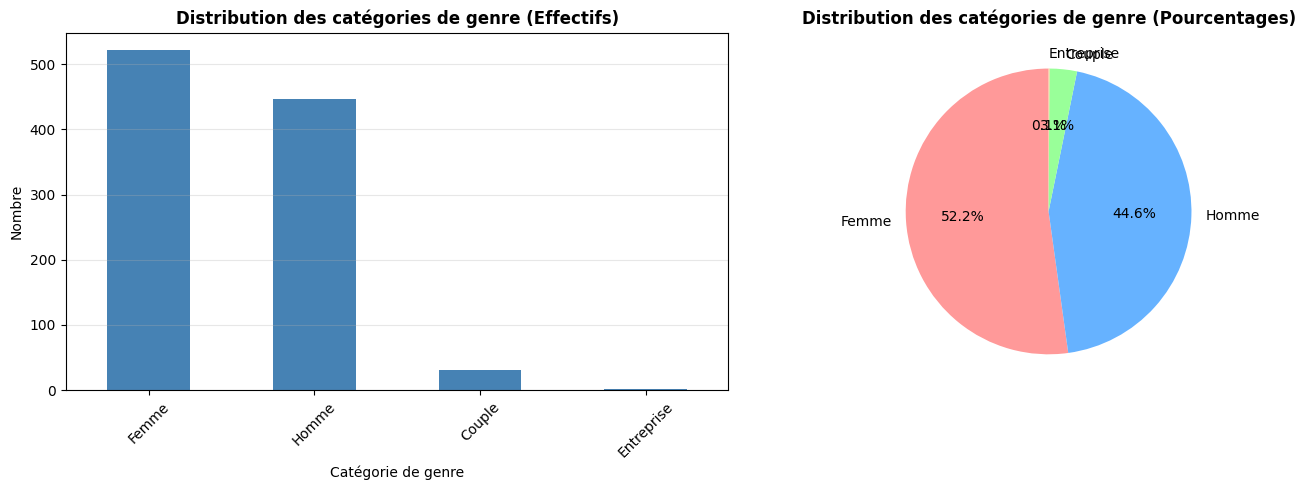

In [39]:
import matplotlib.pyplot as plt

# Calculer la distribution
gender_distribution = df['gender'].value_counts()
print("Distribution des catégories de genre :")
print(gender_distribution)
print("\nPourcentages :")
print((gender_distribution / len(df) * 100).round(2))

# Créer un graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
gender_distribution.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Distribution des catégories de genre (Effectifs)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Catégorie de genre')
ax1.set_ylabel('Nombre')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Graphique en camembert
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
ax2.pie(gender_distribution, labels=gender_distribution.index, autopct='%1.1f%%', 
        startangle=90, colors=colors)
ax2.set_title('Distribution des catégories de genre (Pourcentages)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
